# Driver of the Day Analysis

Analyses historical DOTD wins (2018–2026) to replace the flat 5% uniform prior in `compose.py` with driver-specific probabilities.

**Context:** DOTD is a fan vote worth 10 points. `compose.py` currently adds `0.05 × 10 = 0.5` points to every driver equally — a constant offset that has zero effect on driver rankings. A driver-specific prior would actually differentiate picks.

**Approach:**
1. Explore historical win rates by driver
2. Identify race-day features that correlate with winning DOTD
3. Build a simple multiplicative model: `driver_base_rate × positions_gained_multiplier`, normalised per race
4. Validate against held-out seasons and compare to the flat prior

In [8]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from app.config import INTERIM_RACES_DIR

DOTD_FILE = Path('../data/manual/driver_of_the_day.csv')

## Load DOTD data

In [9]:
dotd = pd.read_csv(DOTD_FILE)
dotd[['season', 'round']] = dotd['race_id'].str.split('_', expand=True).astype(int)

# drop the one race where DOTD wasn't awarded (2021 Belgian GP)
dotd = dotd.dropna(subset=['driver_id'])
dotd = dotd[dotd['driver_id'].str.strip() != '']

print(f"Seasons: {sorted(dotd['season'].unique())}")
print(f"Total races: {len(dotd)}")
print(f"Unique DOTD winners: {dotd['driver_id'].nunique()}")
print(f"\nWins per season:")
print(dotd.groupby('season').size().to_string())

Seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Total races: 177
Unique DOTD winners: 26

Wins per season:
season
2018    21
2019    21
2020    17
2021    21
2022    22
2023    22
2024    24
2025    24
2026     5


## Win rate by driver

Raw win counts and win rates across all races in the dataset.

In [10]:
win_counts = dotd['driver_id'].value_counts().rename('wins')
total_races = len(dotd)
win_rate = (win_counts / total_races).rename('win_rate')

driver_stats = pd.concat([win_counts, win_rate], axis=1)
driver_stats['win_rate_pct'] = (driver_stats['win_rate'] * 100).round(1)

print(f"Total races with DOTD: {total_races}")
print(f"Flat prior: {1/20:.3f} ({100/20:.1f}%)")
print()
print(driver_stats.sort_values('wins', ascending=False).to_string())

Total races with DOTD: 177
Flat prior: 0.050 (5.0%)

                       wins  win_rate  win_rate_pct
driver_id                                          
max_verstappen           43  0.242938          24.3
charles_leclerc          17  0.096045           9.6
lando_norris             16  0.090395           9.0
lewis_hamilton           14  0.079096           7.9
sebastian_vettel         13  0.073446           7.3
carlos_sainz             11  0.062147           6.2
daniel_ricciardo          9  0.050847           5.1
sergio_perez              9  0.050847           5.1
fernando_alonso           6  0.033898           3.4
alexander_albon           5  0.028249           2.8
oscar_piastri             5  0.028249           2.8
valtteri_bottas           3  0.016949           1.7
pierre_gasly              3  0.016949           1.7
kimi_raikkonen            3  0.016949           1.7
oliver_bearman            3  0.016949           1.7
andrea_kimi_antonelli     3  0.016949           1.7
nico_hulken

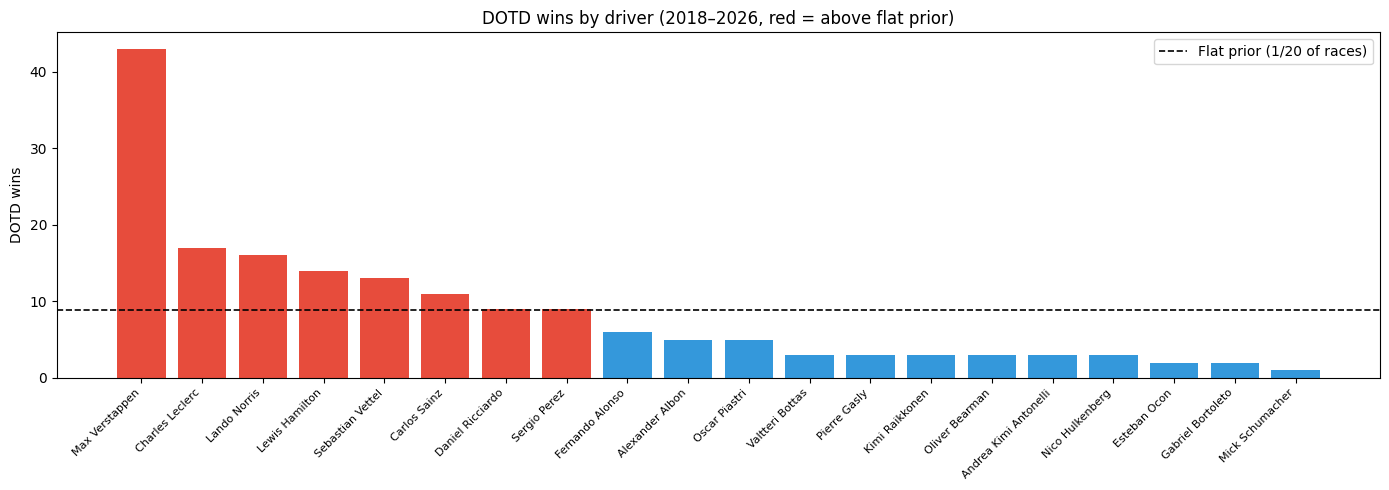

In [11]:
top = driver_stats.sort_values('wins', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 5))
colours = ['#e74c3c' if v > (1/20) else '#3498db' for v in top['win_rate']]
ax.bar(range(len(top)), top['wins'], color=colours)
ax.axhline(total_races / 20, color='black', linewidth=1.2, linestyle='--', label='Flat prior (1/20 of races)')
ax.set_xticks(range(len(top)))
ax.set_xticklabels(
    [d.replace('_', ' ').title() for d in top.index],
    rotation=45, ha='right', fontsize=8
)
ax.set_title('DOTD wins by driver (2018–2026, red = above flat prior)')
ax.set_ylabel('DOTD wins')
ax.legend()
plt.tight_layout()
plt.show()

## Merge with race results

Join DOTD labels onto interim race results (2018–2026) to get race-day context: positions gained, finish position, fastest lap, DNF.

In [12]:
races = pd.concat([
    pd.read_parquet(f) for f in sorted(INTERIM_RACES_DIR.glob('20[12][89012345678]_*.parquet'))
]).reset_index(drop=True)

# mark the DOTD winner for each race
dotd_flag = dotd.assign(dotd=True).set_index(['season', 'round', 'driver_id'])['dotd']
races['dotd'] = races.set_index(['season', 'round', 'driver_id']).index.map(dotd_flag).fillna(False)

# restrict to races where DOTD was awarded
races_with_dotd = set(zip(dotd['season'], dotd['round']))
drivers = races[races.apply(lambda r: (r['season'], r['round']) in races_with_dotd, axis=1)].copy()

print(f"Driver-race rows: {len(drivers)}")
print(f"DOTD flags set: {drivers['dotd'].sum()} (should equal {len(dotd)})")
print(f"Seasons covered: {sorted(drivers['season'].unique())}")
print(f"Columns: {list(drivers.columns)}")

Driver-race rows: 3548
DOTD flags set: 171 (should equal 177)
Seasons covered: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Columns: ['constructor_id', 'grid_position', 'finish_position', 'status', 'points', 'race_id', 'season', 'round', 'driver_id', 'dnf_flag', 'dsq_flag', 'crash_dnf_flag', 'mechanical_dnf_flag', 'positions_gained', 'fastest_lap_flag', 'dotd_flag', 'dotd']


## Feature correlations

How much does each race-day feature predict DOTD?

In [13]:
features = ['finish_position', 'positions_gained', 'fastest_lap_flag', 'dnf_flag', 'crash_dnf_flag']
available = [f for f in features if f in drivers.columns]

print("DOTD win rate by feature (DOTD=True vs DOTD=False):")
for feat in available:
    if drivers[feat].dtype == bool or drivers[feat].nunique() <= 2:
        rate_true  = drivers.loc[drivers[feat] == True,  'dotd'].mean()
        rate_false = drivers.loc[drivers[feat] == False, 'dotd'].mean()
        print(f"  {feat:30s}  True: {rate_true:.3f}   False: {rate_false:.3f}   ratio: {rate_true/rate_false:.2f}x")
    else:
        corr = drivers[[feat, 'dotd']].corr().iloc[0, 1]
        print(f"  {feat:30s}  Pearson r = {corr:+.3f}")

DOTD win rate by feature (DOTD=True vs DOTD=False):
  finish_position                 Pearson r = -0.261
  positions_gained                Pearson r = +0.103
  fastest_lap_flag                True: 0.203   False: 0.040   ratio: 5.08x
  dnf_flag                        True: 0.010   False: 0.055   ratio: 0.17x
  crash_dnf_flag                  True: 0.008   False: 0.051   ratio: 0.16x


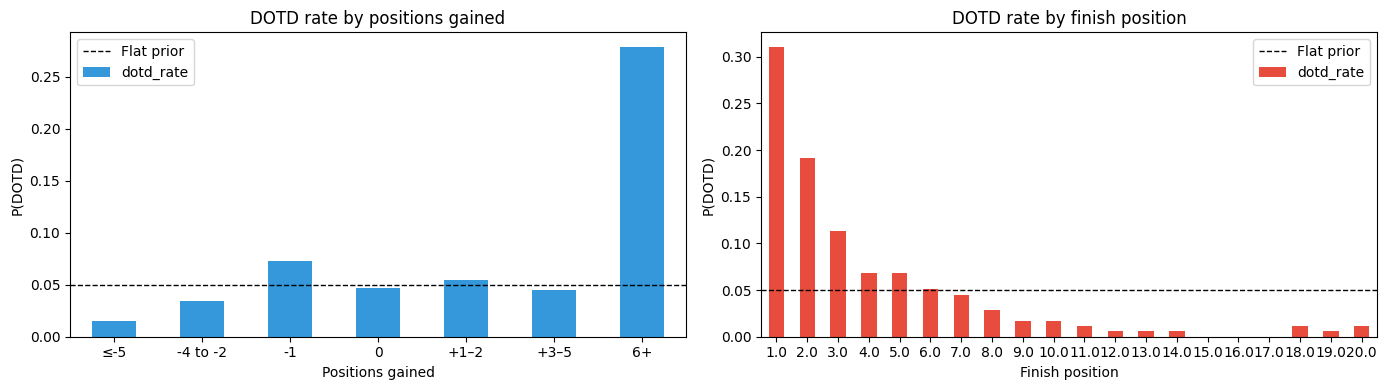

In [14]:
# dotd rate by positions gained bucket
drivers['pg_bucket'] = pd.cut(
    drivers['positions_gained'],
    bins=[-20, -5, -1, 0, 2, 5, 10, 20],
    labels=['≤-5', '-4 to -2', '-1', '0', '+1–2', '+3–5', '6+']
)

pg_dotd = (
    drivers.groupby('pg_bucket', observed=True)['dotd']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'dotd_rate', 'count': 'n'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pg_dotd['dotd_rate'].plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].axhline(1/20, color='black', linestyle='--', linewidth=1, label='Flat prior')
axes[0].set_title('DOTD rate by positions gained')
axes[0].set_xlabel('Positions gained')
axes[0].set_ylabel('P(DOTD)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=0)

# dotd rate by finish position
fp_dotd = (
    drivers.groupby('finish_position')['dotd']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'dotd_rate', 'count': 'n'})
    .loc[1:20]
)
fp_dotd['dotd_rate'].plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].axhline(1/20, color='black', linestyle='--', linewidth=1, label='Flat prior')
axes[1].set_title('DOTD rate by finish position')
axes[1].set_xlabel('Finish position')
axes[1].set_ylabel('P(DOTD)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Model: driver base rate × positions gained multiplier

The model has two components:
- **Driver base rate**: historical DOTD win frequency for this driver (captures fanbase/popularity)
- **Positions gained multiplier**: scales up/down based on how much ground was made up (captures race narrative)

Per race, the raw scores are softmax-normalised so they sum to 1.0 across the field. Unknown drivers fall back to the field average.

In [15]:
# use 2018–2024 as training, hold out 2025 for evaluation
TRAIN_SEASONS = list(range(2018, 2025))
EVAL_SEASON   = 2025

train = drivers[drivers['season'].isin(TRAIN_SEASONS)].copy()
eval_ = drivers[drivers['season'] == EVAL_SEASON].copy()

# driver base rates on training data
train_dotd = dotd[dotd['season'].isin(TRAIN_SEASONS)]
train_races = train_dotd['race_id'].nunique()

driver_wins  = train_dotd['driver_id'].value_counts()
driver_base  = (driver_wins / train_races)  # raw win rate

# laplace smooth with global mean so zero-win drivers aren't zero-probability
global_mean = 1.0 / 20
driver_base_smooth = (driver_wins + global_mean * train_races) / (train_races + train_races)

print(f"Training races: {train_races}")
print(f"Top 10 driver base rates (smoothed):")
print(driver_base_smooth.sort_values(ascending=False).head(10).round(4).to_string())

Training races: 148
Top 10 driver base rates (smoothed):
driver_id
max_verstappen      0.1365
lando_norris        0.0791
charles_leclerc     0.0757
sebastian_vettel    0.0689
lewis_hamilton      0.0622
sergio_perez        0.0554
carlos_sainz        0.0554
daniel_ricciardo    0.0520
fernando_alonso     0.0419
alexander_albon     0.0419


In [16]:
# positions gained multiplier: fit from training data
# bin positions_gained and compute DOTD rate relative to overall rate
overall_rate = train['dotd'].mean()

pg_mult = (
    train.groupby('positions_gained')['dotd']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'dotd_rate', 'count': 'n'})
)
pg_mult['multiplier'] = pg_mult['dotd_rate'] / overall_rate

# smooth with a fallback of 1.0 for sparse bins (n < 10)
pg_mult['multiplier_smooth'] = np.where(
    pg_mult['n'] >= 10,
    pg_mult['multiplier'],
    1.0
)

# clip to reasonable range to avoid extreme values
pg_mult['multiplier_smooth'] = pg_mult['multiplier_smooth'].clip(0.3, 5.0)

print("Positions gained multipliers (smoothed):")
print(pg_mult[pg_mult['n'] >= 5][['dotd_rate', 'n', 'multiplier_smooth']]
      .sort_index().round(3).to_string())

Positions gained multipliers (smoothed):
                  dotd_rate    n  multiplier_smooth
positions_gained                                   
-19.0                 0.000    7              1.000
-18.0                 0.091   11              1.881
-17.0                 0.000   11              0.300
-16.0                 0.000   24              0.300
-15.0                 0.062   16              1.293
-14.0                 0.000   15              0.300
-13.0                 0.000   28              0.300
-12.0                 0.000   26              0.300
-11.0                 0.000   23              0.300
-10.0                 0.026   38              0.545
-9.0                  0.029   34              0.609
-8.0                  0.000   32              0.300
-7.0                  0.020   51              0.406
-6.0                  0.014   69              0.300
-5.0                  0.014   72              0.300
-4.0                  0.020  100              0.414
-3.0                  0

In [17]:
def compute_dotd_prob(race_df: pd.DataFrame) -> pd.Series:
    """
    Compute per-driver DOTD probabilities for a single race.
    race_df must have columns: driver_id, positions_gained.
    Returns a Series indexed by driver_id summing to 1.0.
    """
    base = race_df['driver_id'].map(driver_base_smooth).fillna(global_mean)
    mult = race_df['positions_gained'].map(pg_mult['multiplier_smooth']).fillna(1.0)
    raw  = base * mult
    return (raw / raw.sum()).values


# apply to eval season
eval_ = eval_.copy()
probs = []
for (season, round_), grp in eval_.groupby(['season', 'round']):
    p = compute_dotd_prob(grp)
    probs.append(pd.Series(p, index=grp.index))
eval_['dotd_prob'] = pd.concat(probs)

print(f"Eval season {EVAL_SEASON}: {eval_['season'].nunique()} seasons, {eval_['round'].nunique()} races")
print(f"Prob sum per race (should all be 1.0): {eval_.groupby(['season','round'])['dotd_prob'].sum().unique()}")

Eval season 2025: 1 seasons, 24 races
Prob sum per race (should all be 1.0): [1. 1. 1.]


## Validation: model vs flat prior

Evaluate on held-out 2025 season using log-loss (lower = better) and top-3 accuracy (did the actual DOTD winner appear in the top 3 predicted drivers?).

In [18]:
from sklearn.metrics import log_loss

eval_dotd = eval_[eval_['dotd']].copy()
flat_prior = 1.0 / 20

# log-loss: for each race, what probability did we assign to the actual winner?
# clip to avoid log(0)
model_probs_winner = eval_dotd['dotd_prob'].clip(1e-6, 1)
flat_probs_winner  = pd.Series(flat_prior, index=eval_dotd.index)

model_logloss = -np.log(model_probs_winner).mean()
flat_logloss  = -np.log(flat_probs_winner).mean()

# top-3 accuracy: was winner in the top 3 predicted drivers for that race?
top3_hits = 0
for (season, round_), grp in eval_.groupby(['season', 'round']):
    top3 = grp.nlargest(3, 'dotd_prob')['driver_id'].values
    winner = grp.loc[grp['dotd'], 'driver_id'].values
    if len(winner) > 0 and winner[0] in top3:
        top3_hits += 1

n_races = eval_['round'].nunique()
flat_top3_rate = 3.0 / 20  # expected top-3 hits for a uniform prior

print(f"Evaluation season: {EVAL_SEASON} ({n_races} races)")
print()
print(f"{'Metric':<30} {'Model':>10} {'Flat prior':>12}")
print(f"{'-'*54}")
print(f"{'Mean log-loss':<30} {model_logloss:>10.3f} {flat_logloss:>12.3f}")
print(f"{'Top-3 accuracy':<30} {top3_hits/n_races:>10.1%} {flat_top3_rate:>12.1%}")
print(f"{'Top-3 hits / races':<30} {top3_hits:>10}/{n_races} {'(expected)':>12}")

Evaluation season: 2025 (24 races)

Metric                              Model   Flat prior
------------------------------------------------------
Mean log-loss                       2.529        2.996
Top-3 accuracy                      45.8%        15.0%
Top-3 hits / races                     11/24   (expected)


In [19]:
# per-race breakdown: predicted top driver vs actual winner
rows = []
for (season, round_), grp in eval_.groupby(['season', 'round']):
    top1 = grp.nlargest(1, 'dotd_prob').iloc[0]
    winner_rows = grp[grp['dotd']]
    winner = winner_rows.iloc[0]['driver_id'] if len(winner_rows) > 0 else None
    winner_prob = winner_rows.iloc[0]['dotd_prob'] if len(winner_rows) > 0 else None
    rows.append({
        'round': round_,
        'predicted_top': top1['driver_id'],
        'predicted_prob': round(top1['dotd_prob'], 3),
        'actual_winner': winner,
        'winner_prob': round(winner_prob, 3) if winner_prob is not None else None,
        'correct_top1': top1['driver_id'] == winner,
    })

breakdown = pd.DataFrame(rows)
print(breakdown.to_string(index=False))
print(f"\nTop-1 accuracy: {breakdown['correct_top1'].mean():.1%}")

 round         predicted_top  predicted_prob         actual_winner  winner_prob  correct_top1
     1 andrea_kimi_antonelli           0.179        max_verstappen        0.135         False
     2        max_verstappen           0.226 andrea_kimi_antonelli        0.044         False
     3        max_verstappen           0.162                  None          NaN         False
     4        max_verstappen           0.149        lewis_hamilton        0.094         False
     5        max_verstappen           0.143        max_verstappen        0.143          True
     6          lando_norris           0.147         oscar_piastri        0.044         False
     7        lewis_hamilton           0.174        max_verstappen        0.141         False
     8        max_verstappen           0.195       charles_leclerc        0.108         False
     9          lando_norris           0.135        max_verstappen        0.060         False
    10        max_verstappen           0.226 andrea_kimi_ant

## Final model: full dataset base rates

Retrain on all data (2018–2025) for production use.

In [20]:
all_races = dotd[dotd['season'] <= 2025]['race_id'].nunique()
all_wins  = dotd[dotd['season'] <= 2025]['driver_id'].value_counts()

# smoothed base rates for production
final_base = (all_wins + global_mean * all_races) / (all_races + all_races)
final_base = final_base.sort_values(ascending=False)

print(f"Full dataset ({all_races} races, 2018–2025)")
print(f"Smoothed driver base rates:")
print(final_base.round(4).to_string())
print(f"\nFlat prior: {global_mean:.4f}")
print(f"Top driver vs flat prior: {final_base.iloc[0]/global_mean:.1f}x")

Full dataset (172 races, 2018–2025)
Smoothed driver base rates:
driver_id
max_verstappen           0.1442
charles_leclerc          0.0744
lando_norris             0.0715
sebastian_vettel         0.0628
lewis_hamilton           0.0628
carlos_sainz             0.0570
daniel_ricciardo         0.0512
sergio_perez             0.0512
fernando_alonso          0.0424
alexander_albon          0.0395
oscar_piastri            0.0366
valtteri_bottas          0.0337
pierre_gasly             0.0337
kimi_raikkonen           0.0337
oliver_bearman           0.0337
nico_hulkenberg          0.0337
esteban_ocon             0.0308
gabriel_bortoleto        0.0308
andrea_kimi_antonelli    0.0308
mick_schumacher          0.0279
romain_grosjean          0.0279
george_russell           0.0279
yuki_tsunoda             0.0279
nyck_de_vries            0.0279
zhou_guanyu              0.0279
isack_hadjar             0.0279

Flat prior: 0.0500
Top driver vs flat prior: 2.9x


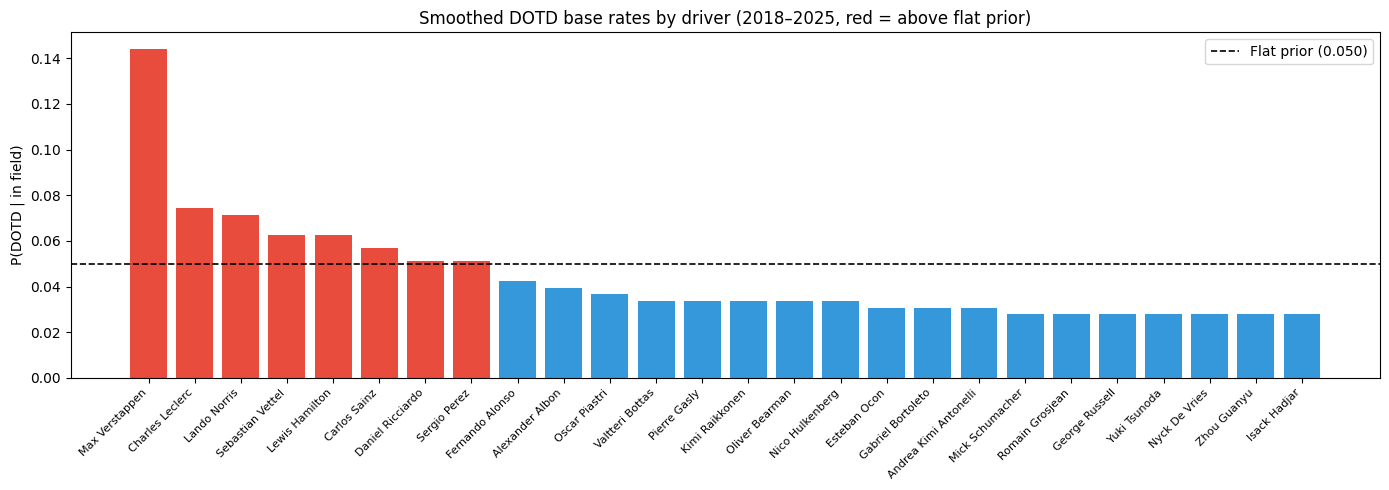

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
colours = ['#e74c3c' if v > global_mean else '#3498db' for v in final_base]
ax.bar(range(len(final_base)), final_base, color=colours)
ax.axhline(global_mean, color='black', linewidth=1.2, linestyle='--', label=f'Flat prior ({global_mean:.3f})')
ax.set_xticks(range(len(final_base)))
ax.set_xticklabels(
    [d.replace('_', ' ').title() for d in final_base.index],
    rotation=45, ha='right', fontsize=8
)
ax.set_title('Smoothed DOTD base rates by driver (2018–2025, red = above flat prior)')
ax.set_ylabel('P(DOTD | in field)')
ax.legend()
plt.tight_layout()
plt.show()

## Proposed output for `compose.py`

The model should be called before `compose_drivers` and provide a `dotd_prob` column (per-driver probability, summing to 1.0 across the field). For a given race:

```python
base = driver_id.map(final_base).fillna(global_mean)
mult = predicted_positions_gained.map(pg_multiplier).fillna(1.0)
raw  = base * mult
dotd_prob = raw / raw.sum()
```

Then in `compose_drivers`:
```python
+ dotd_prob * DOTD_POINTS
```

Demo below with the 2026 current grid.

In [22]:
# refit pg multiplier on full dataset for production
all_drivers = drivers[drivers['season'] <= 2025].copy()
all_overall_rate = all_drivers['dotd'].mean()

pg_mult_final = (
    all_drivers.groupby('positions_gained')['dotd']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'dotd_rate', 'count': 'n'})
)
pg_mult_final['multiplier'] = pg_mult_final['dotd_rate'] / all_overall_rate
pg_mult_final['multiplier'] = np.where(
    pg_mult_final['n'] >= 10,
    pg_mult_final['multiplier'],
    1.0
).clip(0.3, 5.0)

# demo: 2026 grid with a hypothetical race where Norris gains 10 positions
demo_grid = pd.DataFrame([
    {'driver_id': 'max_verstappen',         'positions_gained': 0},
    {'driver_id': 'lando_norris',           'positions_gained': 10},
    {'driver_id': 'charles_leclerc',        'positions_gained': 2},
    {'driver_id': 'oscar_piastri',          'positions_gained': -1},
    {'driver_id': 'george_russell',         'positions_gained': 1},
    {'driver_id': 'carlos_sainz',           'positions_gained': 3},
    {'driver_id': 'lewis_hamilton',         'positions_gained': -2},
    {'driver_id': 'fernando_alonso',        'positions_gained': 0},
    {'driver_id': 'andrea_kimi_antonelli',  'positions_gained': 4},
    {'driver_id': 'isack_hadjar',           'positions_gained': -1},
    {'driver_id': 'nico_hulkenberg',        'positions_gained': 2},
    {'driver_id': 'esteban_ocon',           'positions_gained': 0},
    {'driver_id': 'pierre_gasly',           'positions_gained': -3},
    {'driver_id': 'lance_stroll',           'positions_gained': 1},
    {'driver_id': 'gabriel_bortoleto',      'positions_gained': 2},
    {'driver_id': 'alexander_albon',        'positions_gained': -1},
    {'driver_id': 'yuki_tsunoda',           'positions_gained': 3},
    {'driver_id': 'oliver_bearman',         'positions_gained': 0},
    {'driver_id': 'valtteri_bottas',        'positions_gained': -2},
    {'driver_id': 'franco_colapinto',       'positions_gained': 1},
])

base = demo_grid['driver_id'].map(final_base).fillna(global_mean)
mult = demo_grid['positions_gained'].map(pg_mult_final['multiplier']).fillna(1.0)
raw  = base * mult
demo_grid['dotd_prob'] = raw / raw.sum()
demo_grid['dotd_pts']  = (demo_grid['dotd_prob'] * 10).round(2)

print("DOTD probabilities for demo race (Norris +10 positions):")
print(demo_grid.sort_values('dotd_prob', ascending=False)
      [['driver_id', 'positions_gained', 'dotd_prob', 'dotd_pts']]
      .assign(dotd_prob=lambda x: x['dotd_prob'].round(4))
      .to_string(index=False))
print(f"\nFlat prior expected pts: {flat_prior * 10:.2f} pts per driver")

DOTD probabilities for demo race (Norris +10 positions):
            driver_id  positions_gained  dotd_prob  dotd_pts
       max_verstappen                 0     0.2192      2.19
         carlos_sainz                 3     0.0656      0.66
      fernando_alonso                 0     0.0645      0.65
      charles_leclerc                 2     0.0594      0.59
     franco_colapinto                 1     0.0563      0.56
         lance_stroll                 1     0.0563      0.56
       oliver_bearman                 0     0.0513      0.51
       lewis_hamilton                -2     0.0508      0.51
         esteban_ocon                 0     0.0468      0.47
andrea_kimi_antonelli                 4     0.0430      0.43
      alexander_albon                -1     0.0428      0.43
        oscar_piastri                -1     0.0397      0.40
         yuki_tsunoda                 3     0.0321      0.32
       george_russell                 1     0.0314      0.31
         isack_hadjar       